# Домашнее задание 1. Первичный анализ данных (Python)

**Цель:** научиться загружать данные из разных форматов, выполнять первичный анализ и
преобразовывать таблицы.

**Входные данные** (папка `data`):

* `Steel_Industry.csv` — данные энергопотребления сталелитейного предприятия (35 040 строк);
* `температура.txt` — вектор температуры окружающей среды.

**Как выполнять.** В ячейках заменить`...` на свой код. После каждой задачи
идёт ячейка самопроверки — запустите её, чтобы увидеть ✅ или ❌. Все шесть задач решаются
одной строкой кода.

**Важно:** код должен сохранять результат в переменную, указанную в задании (обычно `ans`).

## Подготовительная ячейка — выполните её перед началом работы

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA = Path("data")
plt.rcParams["figure.figsize"] = (11, 5)

EXPECTED = {
    1: (35040, 11),
    2: [3.17, 4.0, 3.24, 3.31, 3.82, 3.28, 3.6, 3.6, 3.28, 3.78],
    3: 35040,
    4: (-28.9, 37.4),
    5: ["date", "Usage_kWh", "Lagging_Current_Reactive_Power_kVarh",
        "Leading_Current_Reactive_Power_kVarh", "CO2_tCO2_",
        "Lagging_Current_Power_Factor", "Leading_Current_Power_Factor"],
    6: [-12.3, -9.8, -9.7],
}


def _brief(v):
    """Компактное представление ответа для печати."""
    if isinstance(v, (pd.Series, np.ndarray)):
        return list(np.round(np.asarray(v, dtype=object), 4)) if v.dtype == object else v.tolist()
    return v


def check(task, value):
    """Сравнивает ответ с эталоном и печатает вердикт."""
    expected = EXPECTED[task]
    try:
        if value is None or (isinstance(value, type(Ellipsis))):
            print(f"❌ Задание {task}: ответ не заполнен")
            return
        if isinstance(expected, tuple) and not isinstance(value, (list, np.ndarray, pd.Series)):
            ok = tuple(np.round(np.array(value, dtype=float), 6)) == tuple(
                np.round(np.array(expected, dtype=float), 6))
        elif isinstance(expected, list) and isinstance(expected[0], str):
            ok = list(value) == expected
        elif isinstance(expected, list):
            got = np.asarray(pd.Series(value).tolist(), dtype=float)
            ok = got.shape == np.array(expected).shape and np.allclose(got, expected)
        else:
            ok = np.isclose(float(value), float(expected))
    except Exception as e:
        print(f"❌ Задание {task}: не удалось сравнить ответ ({type(e).__name__}: {e})")
        return
    print(f"{'✅' if ok else '❌'} Задание {task}: ваш ответ {_brief(value)}")
    if not ok:
        print(f"   ожидалось: {expected}")


print("Папка с данными найдена:", DATA.exists())
print("Файлы:", [f.name for f in sorted(DATA.iterdir())])

Папка с данными найдена: True
Файлы: ['Steel_Industry.csv', 'температура.txt']


## Задание 1

Выведите размерность набора данных `df_energy` (число строк и столбцов).

**Подсказка:** у объекта `DataFrame` есть атрибут `.shape` — он возвращает кортеж
`(строки, столбцы)`. Атрибут пишется **без круглых скобок**.

*Ожидаемый результат:* `(35040, 11)`

In [2]:
df_energy = pd.read_csv(DATA / "Steel_Industry.csv")

ans = df_energy.shape
print(ans)

(35040, 11)


In [3]:
check(1, ans)

✅ Задание 1: ваш ответ (35040, 11)


## Задание 2

Выведите первые десять значений столбца `Usage_kWh` из набора данных `df_energy`.

**Подсказка:** к столбцу обращаются как `df_energy["Usage_kWh"]`, а первые `n` строк
возвращает метод `.head(n)`. Обратите внимание: `.head()` — это метод, скобки обязательны.

*Ожидаемый результат:* `[3.17, 4.0, 3.24, 3.31, 3.82, 3.28, 3.6, 3.6, 3.28, 3.78]`

In [4]:
df_energy = pd.read_csv(DATA / "Steel_Industry.csv")

ans = df_energy.loc[:, "Usage_kWh"].iloc[:10]
print(ans)

0    3.17
1    4.00
2    3.24
3    3.31
4    3.82
5    3.28
6    3.60
7    3.60
8    3.28
9    3.78
Name: Usage_kWh, dtype: float64


In [5]:
check(2, ans)

✅ Задание 2: ваш ответ [3.17, 4.0, 3.24, 3.31, 3.82, 3.28, 3.6, 3.6, 3.28, 3.78]


## Задание 3

Выведите количество элементов вектора температуры окружающей среды `temperature`.

**Подсказка:** длину одномерного массива возвращает встроенная функция `len()`
(либо атрибут `.size` у массива numpy).

*Ожидаемый результат:* `35040`

In [6]:
temperature = np.loadtxt(DATA / "температура.txt")

ans = temperature.size
print(ans)

35040


In [7]:
check(3, ans)

✅ Задание 3: ваш ответ 35040


## Задание 4

Найдите минимальное и максимальное значение вектора `temperature`. Результат — кортеж
вида `(мин, макс)`.

**Подсказка:** у массива numpy есть методы `.min()` и `.max()`. Кортеж из двух значений
записывается так: `(a, b)`. Можно обойтись одной функцией — `np.ptp` тут не подойдёт,
а вот `(x.min(), x.max())` подойдёт.

*Ожидаемый результат:* `(-28.9, 37.4)`

In [8]:
temperature = np.loadtxt(DATA / "температура.txt")

ans = (np.min(temperature), np.max(temperature))
print(ans)

(np.float64(-28.9), np.float64(37.4))


In [9]:
check(4, ans)

✅ Задание 4: ваш ответ (np.float64(-28.9), np.float64(37.4))


## Задание 5

Удалите столбцы `NSM`, `WeekStatus`, `Day_of_week`, `Load_Type` из набора данных `df_energy`
и запишите список оставшихся имён столбцов в переменную `ans`.

**Подсказка:**

1. удаление: `df_energy = df_energy.drop(columns=[...])` — имена столбцов перечисляются
   строками в списке;
2. список имён столбцов: `list(df_energy.columns)`.

*Ожидаемый результат:* 7 имён, начиная с `date` и заканчивая `Leading_Current_Power_Factor`.

In [10]:
df_energy = pd.read_csv(DATA / "Steel_Industry.csv")

df_energy = df_energy.drop(columns=["NSM", "WeekStatus", "Day_of_week", "Load_Type"])
ans = df_energy.columns.tolist()
print(ans)

['date', 'Usage_kWh', 'Lagging_Current_Reactive_Power_kVarh', 'Leading_Current_Reactive_Power_kVarh', 'CO2_tCO2_', 'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor']


In [11]:
check(5, ans)

✅ Задание 5: ваш ответ ['date', 'Usage_kWh', 'Lagging_Current_Reactive_Power_kVarh', 'Leading_Current_Reactive_Power_kVarh', 'CO2_tCO2_', 'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor']


## Задание 6

Добавьте в набор данных `df_energy` столбец `Temperature_C` и присвойте ему значения
вектора `temperature`.

**Подсказка:** новый столбец создаётся присваиванием по имени:
`df["new_column"] = new_vector`. Длина вектора должна совпадать с числом
строк таблицы.

*Ожидаемый результат:* первые три значения нового столбца — `[-12.3, -9.8, -9.7]`.

In [12]:
df_energy = pd.read_csv(DATA / "Steel_Industry.csv")
temperature = np.loadtxt(DATA / "температура.txt")

df_energy = df_energy.assign(Temperature_C=temperature)

ans = df_energy["Temperature_C"].iloc[:3]
print(ans.tolist())

# Новый столбец находится в конце таблицы
df_energy.head()

[-12.3, -9.8, -9.7]


,date,Usage_kWh,Lagging_Current_Reactive_Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2_tCO2_,Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type,Temperature_C
0,01/01/2018 00:15,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load,-12.3
1,01/01/2018 00:30,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load,-9.8
2,01/01/2018 00:45,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load,-9.7
3,01/01/2018 01:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load,-10.9
4,01/01/2018 01:15,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load,-13.4


In [13]:
check(6, ans)

✅ Задание 6: ваш ответ [-12.3, -9.8, -9.7]


## Заключение

Задания решены — построим графики по итоговой таблице и посмотрим на результат.

Поменяйте имена столбцов в переменных `var_plot1` и `var_plot2`, чтобы посмотреть на другие
параметры. Доступные варианты: `Usage_kWh`, `Lagging_Current_Reactive_Power_kVarh`,
`Leading_Current_Reactive_Power_kVarh`, `CO2_tCO2_`, `Lagging_Current_Power_Factor`,
`Leading_Current_Power_Factor`, `Temperature_C`.

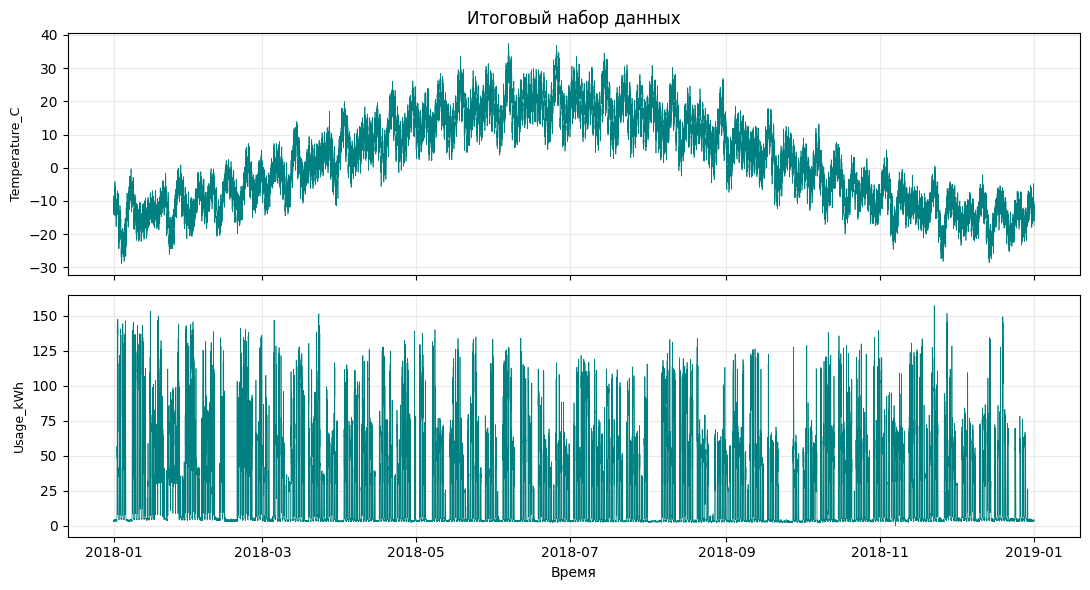

In [14]:
var_plot1 = "Temperature_C"
var_plot2 = "Usage_kWh"

df_energy["DateTime"] = pd.to_datetime(df_energy["date"], format="%d/%m/%Y %H:%M")
df_plot = df_energy.sort_values("DateTime")

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
for ax, name in zip(axes, [var_plot1, var_plot2]):
    ax.plot(df_plot["DateTime"], df_plot[name], linewidth=0.5, color="teal")
    ax.set_ylabel(name, fontsize=9)
    ax.grid(alpha=0.25)
axes[-1].set_xlabel("Время")
axes[0].set_title("Итоговый набор данных")
plt.tight_layout()
plt.show()